1: Install Dependencies

In [1]:
# Install required packages
!pip install -q tensorflow tensorflow-hub librosa soundfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import librosa
import soundfile as sf
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers, regularizers  # ← ADD regularizers HERE
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


2025-11-11 13:54:02.481169: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762869242.658610      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762869242.706185      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow version: 2.18.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2: Set Parameters and Paths

In [2]:
# Parameters
SAMPLE_RATE = 16000  # YAMNet expects 16kHz
MAX_DURATION = 10  # Maximum audio length in seconds
RANDOM_SEED = 42
BATCH_SIZE = 32
EPOCHS = 100

# Dataset path - adjust to your Kaggle dataset location
DATASET_PATH = '/kaggle/input/capstonepaperdataset/freesound_dataset_renamed'

# Classes
CLASSES = ['cry', 'laugh', 'scream', 'shout', 'sing', 'talk']
NUM_CLASSES = len(CLASSES)

print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {CLASSES}")

# Set seeds for reproducibility
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


Number of classes: 6
Classes: ['cry', 'laugh', 'scream', 'shout', 'sing', 'talk']


3: Load and Explore Dataset

cry: 150 files
laugh: 150 files
scream: 150 files
shout: 150 files
sing: 150 files
talk: 150 files

Total audio files: 900

Class distribution:
class
cry       150
laugh     150
scream    150
shout     150
sing      150
talk      150
Name: count, dtype: int64


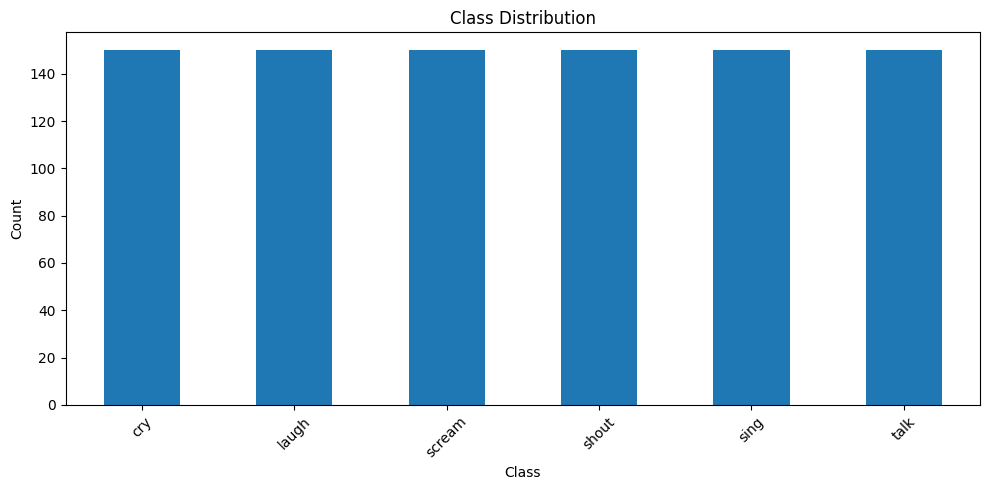

In [3]:
# Create dataset dataframe
data = []
for class_name in CLASSES:
    class_path = os.path.join(DATASET_PATH, class_name)
    audio_files = list(Path(class_path).glob('*.wav'))
    
    for audio_file in audio_files:
        data.append({
            'filepath': str(audio_file),
            'class': class_name,
            'class_id': CLASSES.index(class_name)
        })
    
    print(f"{class_name}: {len(audio_files)} files")

df = pd.DataFrame(data)
print(f"\nTotal audio files: {len(df)}")
print(f"\nClass distribution:")
print(df['class'].value_counts())

# Visualize class distribution
plt.figure(figsize=(10, 5))
df['class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


4: Audio Processing Functions

In [4]:
def load_audio(filepath, sr=16000, duration=10):
    """Load and preprocess audio file"""
    try:
        # Load audio
        audio, orig_sr = librosa.load(filepath, sr=sr, duration=duration)
        
        # Pad or trim to fixed length
        target_length = sr * duration
        if len(audio) < target_length:
            # Pad with zeros
            audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
        else:
            # Trim
            audio = audio[:target_length]
        
        return audio
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def test_audio_loading(df, num_samples=3):
    """Test loading a few audio files"""
    print("Testing audio loading...")
    for i in range(num_samples):
        filepath = df.iloc[i]['filepath']
        audio = load_audio(filepath)
        if audio is not None:
            print(f"✓ Loaded {filepath.split('/')[-1]}: shape {audio.shape}, dtype {audio.dtype}")
        else:
            print(f"✗ Failed to load {filepath}")

test_audio_loading(df)


Testing audio loading...
✓ Loaded cry55.wav: shape (160000,), dtype float32
✓ Loaded cry149.wav: shape (160000,), dtype float32
✓ Loaded cry38.wav: shape (160000,), dtype float32


5: Load YAMNet Model

In [5]:
# Load YAMNet from TensorFlow Hub
print("Loading YAMNet model...")
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')
print("✓ YAMNet loaded successfully!")

# Test YAMNet on a single audio file
test_audio = load_audio(df.iloc[0]['filepath'])
test_audio_tensor = tf.convert_to_tensor(test_audio, dtype=tf.float32)

# YAMNet returns: scores, embeddings, spectrogram
scores, embeddings, spectrogram = yamnet_model(test_audio_tensor)
print(f"\nYAMNet output shapes:")
print(f"  Scores: {scores.shape} - predictions for 521 AudioSet classes")
print(f"  Embeddings: {embeddings.shape} - frame-level 1024-dim embeddings")
print(f"  Spectrogram: {spectrogram.shape}")


Loading YAMNet model...


I0000 00:00:1762869270.230008      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✓ YAMNet loaded successfully!


I0000 00:00:1762869278.992405      74 cuda_dnn.cc:529] Loaded cuDNN version 90300



YAMNet output shapes:
  Scores: (20, 521) - predictions for 521 AudioSet classes
  Embeddings: (20, 1024) - frame-level 1024-dim embeddings
  Spectrogram: (1008, 64)


6: Extract YAMNet Embeddings for All Audio

In [6]:
def extract_yamnet_embedding(filepath):
    """Extract mean YAMNet embedding for an audio file"""
    try:
        # Load audio
        audio = load_audio(filepath)
        if audio is None:
            return None
        
        # Convert to tensor
        audio_tensor = tf.convert_to_tensor(audio, dtype=tf.float32)
        
        # Get embeddings
        _, embeddings, _ = yamnet_model(audio_tensor)
        
        # Average across time frames to get single 1024-dim vector
        mean_embedding = tf.reduce_mean(embeddings, axis=0)
        
        return mean_embedding.numpy()
    except Exception as e:
        print(f"Error extracting embedding for {filepath}: {e}")
        return None

# Extract embeddings for all audio files
print("Extracting YAMNet embeddings for all audio files...")
print("This may take 10-15 minutes...")

embeddings_list = []
labels_list = []
failed_files = []

for idx, row in df.iterrows():
    embedding = extract_yamnet_embedding(row['filepath'])
    
    if embedding is not None:
        embeddings_list.append(embedding)
        labels_list.append(row['class_id'])
    else:
        failed_files.append(row['filepath'])
    
    # Progress indicator
    if (idx + 1) % 50 == 0:
        print(f"Processed {idx + 1}/{len(df)} files...")

# Convert to numpy arrays
X = np.array(embeddings_list)
y = np.array(labels_list)

print(f"\n✓ Extraction complete!")
print(f"Embeddings shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Failed files: {len(failed_files)}")

if failed_files:
    print("Failed files:", failed_files[:5])


Extracting YAMNet embeddings for all audio files...
This may take 10-15 minutes...
Processed 50/900 files...
Processed 100/900 files...
Error loading /kaggle/input/capstonepaperdataset/freesound_dataset_renamed/cry/cry1.wav: 
Processed 150/900 files...
Processed 200/900 files...
Processed 250/900 files...
Processed 300/900 files...
Error loading /kaggle/input/capstonepaperdataset/freesound_dataset_renamed/scream/scream1.wav: 
Processed 350/900 files...
Processed 400/900 files...
Processed 450/900 files...
Processed 500/900 files...
Processed 550/900 files...
Processed 600/900 files...
Processed 650/900 files...
Processed 700/900 files...
Processed 750/900 files...
Processed 800/900 files...
Processed 850/900 files...
Processed 900/900 files...

✓ Extraction complete!
Embeddings shape: (898, 1024)
Labels shape: (898,)
Failed files: 2
Failed files: ['/kaggle/input/capstonepaperdataset/freesound_dataset_renamed/cry/cry1.wav', '/kaggle/input/capstonepaperdataset/freesound_dataset_renamed/s

7: Train/Val/Test Split

In [7]:
# Train/Val/Test Split
print("="*60)
print("TRAIN/VAL/TEST SPLIT")
print("="*60)

# First split: 80% train, 20% temp
X_train, X_temp, y_train_temp, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# Second split: 50% val, 50% test from temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED, stratify=y_temp
)

# IMPORTANT: y_train needs to match the split
y_train = y_train_temp

print("Dataset splits:")
print(f" Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f" Val: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f" Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Check class distribution in splits
print("\nClass distribution in splits:")
for split_name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n{split_name}:")
    unique, counts = np.unique(y_split, return_counts=True)
    for class_id, count in zip(unique, counts):
        print(f" {CLASSES[class_id]:8s}: {count}")

print("\n✓ Splits created!")



TRAIN/VAL/TEST SPLIT
Dataset splits:
 Train: 718 samples (80.0%)
 Val: 90 samples (10.0%)
 Test: 90 samples (10.0%)

Class distribution in splits:

Train:
 cry     : 119
 laugh   : 120
 scream  : 119
 shout   : 120
 sing    : 120
 talk    : 120

Val:
 cry     : 15
 laugh   : 15
 scream  : 15
 shout   : 15
 sing    : 15
 talk    : 15

Test:
 cry     : 15
 laugh   : 15
 scream  : 15
 shout   : 15
 sing    : 15
 talk    : 15

✓ Splits created!


7A: Compute Class Weights

In [8]:
# Compute class weights to handle any imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert to dictionary
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for class_id, weight in class_weight_dict.items():
    print(f"  {CLASSES[class_id]}: {weight:.4f}")


Class weights:
  cry: 1.0056
  laugh: 0.9972
  scream: 1.0056
  shout: 0.9972
  sing: 0.9972
  talk: 0.9972


In [9]:
def targeted_augmentation(X, y, weak_classes=[2, 0], aug_factors={'weak': 7, 'normal': 3}):
    X_aug = []
    y_aug = []
    for emb, label in zip(X, y):
        # Select augmentation factor for this class
        n_aug = aug_factors['weak'] if label in weak_classes else aug_factors['normal']
        # Add original
        X_aug.append(emb)
        y_aug.append(label)
        # Make n_aug augmentations
        for i in range(n_aug):
            if i % 3 == 0:
                noise = np.random.normal(0, 0.05, emb.shape)
                X_aug.append(emb + noise)
                y_aug.append(label)
            elif i % 3 == 1:
                mask = np.random.binomial(1, 0.9, emb.shape)
                X_aug.append(emb * mask)
                y_aug.append(label)
            else:
                scale = np.random.uniform(0.9, 1.1)
                X_aug.append(emb * scale)
                y_aug.append(label)
    return np.array(X_aug), np.array(y_aug)


In [10]:
# Apply targeted augmentation: 8x weak (cry, scream), 4x normal
print("="*60)
print("APPLYING TARGETED AUGMENTATION")
print("="*60)

X_train_tgt, y_train_tgt = targeted_augmentation(
    X_train, 
    y_train, 
    weak_classes=[0, 2],  # cry=0, scream=2
    aug_factors={'weak': 7, 'normal': 3}  # 8x total for weak, 4x for normal
)

print(f"\nAfter targeted augmentation:")
print(f"Train shape: {X_train_tgt.shape}")
for class_id in range(NUM_CLASSES):
    count = np.sum(y_train_tgt == class_id)
    print(f"Class {CLASSES[class_id]}: {count} samples")


APPLYING TARGETED AUGMENTATION

After targeted augmentation:
Train shape: (3824, 1024)
Class cry: 952 samples
Class laugh: 480 samples
Class scream: 952 samples
Class shout: 480 samples
Class sing: 480 samples
Class talk: 480 samples


In [11]:
shallow_model = keras.Sequential([
    layers.Input(shape=(1024,)),
    layers.Dense(768, activation='relu', kernel_regularizer=regularizers.l2(0.01)),  # 768!
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

shallow_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

shallow_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 768)            │       787,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 768)            │         3,072 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 988,678 (3.77 MB)

 Trainable params: 987,142 (3.77 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [12]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=25,  # IMPORTANT!
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'final_best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

history = shallow_model.fit(
    X_train_tgt, y_train_tgt,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)


Epoch 1/100


I0000 00:00:1762869306.041462      71 service.cc:148] XLA service 0x7b05c000b100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762869306.041983      71 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 69/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4552 - loss: 12.4121

I0000 00:00:1762869307.864234      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4796 - loss: 11.2513
Epoch 1: val_accuracy improved from -inf to 0.52222, saving model to final_best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4799 - loss: 11.2325 - val_accuracy: 0.5222 - val_loss: 6.3029 - learning_rate: 0.0010
Epoch 2/100
117/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6123 - loss: 5.2597
Epoch 2: val_accuracy did not improve from 0.52222
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6121 - loss: 5.2418 - val_accuracy: 0.4111 - val_loss: 4.0625 - learning_rate: 0.0010
Epoch 3/100
116/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6220 - loss: 3.4638
Epoch 3: val_accuracy improved from 0.52222 to 0.53333, saving model to final_best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6219 - loss: 3.4524 - val_accuracy: 0.5333 - val_loss: 3.0072 - learning_rate: 0.0010
Epoch 4/100
116/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6376 - loss: 2.5590

In [13]:
from sklearn.metrics import classification_report

y_pred = np.argmax(shallow_model.predict(X_test), axis=1)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2%}")
print(classification_report(y_test, y_pred,target_names=CLASSES))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Test Accuracy: 84.44%
              precision    recall  f1-score   support

         cry       0.92      0.73      0.81        15
       laugh       0.82      0.93      0.87        15
      scream       0.93      0.87      0.90        15
       shout       0.85      0.73      0.79        15
        sing       0.76      0.87      0.81        15
        talk       0.82      0.93      0.87        15

    accuracy                           0.84        90
   macro avg       0.85      0.84      0.84        90
weighted avg       0.85      0.84      0.84        90



In [14]:
# import datetime
# timestamp = datetime.datetime.now().strftime("%Y%m%d%H%M")
# model_save_name = f"yamnet_shallow6c_seed{RANDOM_SEED}_bestacc{88.42:.2f}_{timestamp}.keras"
# shallow_model.save(model_save_name)
# print(f"Model saved to {model_save_name}")


Testing with 3 different seeds

In [15]:
import os

seeds = [42, 123, 2024]
results = []

os.makedirs("saved_models", exist_ok=True)


In [16]:
from tensorflow import keras
from sklearn.metrics import accuracy_score

for seed in seeds:
    print(f"\n=== Running experiment with RANDOM_SEED={seed} ===")
    
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # Split data with stratify and seed
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp
    )
    
    # Apply targeted augmentation with correct factors
    X_train_tgt, y_train_tgt = targeted_augmentation(
        X_train, y_train,
        weak_classes=[2, 0], aug_factors={'weak': 7, 'normal': 3}
    )
    
    # Build model (same shallow architecture)
    model = keras.Sequential([
        keras.layers.Input(shape=(1024,)),
        keras.layers.Dense(768, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # Callbacks
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=25, restore_best_weights=True, verbose=1
    )
    reduce_lr = keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy', factor=0.5, patience=10, min_lr=1e-6, verbose=1
    )
    checkpoint_path = f"saved_models/final_best_model_seed{seed}.keras"
    checkpoint = keras.callbacks.ModelCheckpoint(
        checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1
    )
    
    # Train
    history = model.fit(
        X_train_tgt, y_train_tgt,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr, checkpoint],
        verbose=1
    )
    
    # Load best model and evaluate on test
    best_model = keras.models.load_model(checkpoint_path)
    y_pred_prob = best_model.predict(X_test)
    y_pred = y_pred_prob.argmax(axis=1)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Test accuracy for seed {seed}: {acc:.4f}")
    
    # Save results for later aggregation
    results.append({'seed': seed, 'accuracy': acc, 'model_path': checkpoint_path})



=== Running experiment with RANDOM_SEED=42 ===
Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4868 - loss: 11.1804
Epoch 1: val_accuracy improved from -inf to 0.51111, saving model to saved_models/final_best_model_seed42.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.4871 - loss: 11.1621 - val_accuracy: 0.5111 - val_loss: 6.1060 - learning_rate: 0.0010
Epoch 2/100
111/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6014 - loss: 5.2794
Epoch 2: val_accuracy did not improve from 0.51111
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6012 - loss: 5.2322 - val_accuracy: 0.4778 - val_loss: 4.0746 - learning_rate: 0.0010
Epoch 3/100
114/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6231 - loss: 3.4857
Epoch 3: val_accuracy improved from 0.51111 to 0.57778, saving model to saved_models/final_best_model_seed42.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6228 - loss: 3.4693 - val_accuracy: 0.5778 - val_loss: 2.9257 - learning

In [17]:
import numpy as np

accs = [r['accuracy'] for r in results]
mean_acc = np.mean(accs)
std_acc = np.std(accs)

print(f"\nSummary of results for {len(seeds)} seeds:")
for r in results:
    print(f"Seed {r['seed']}: Test Accuracy = {r['accuracy']:.4f}, Model saved at {r['model_path']}")
print(f"Mean test accuracy: {mean_acc:.4f}")
print(f"Std deviation: {std_acc:.4f}")



Summary of results for 3 seeds:
Seed 42: Test Accuracy = 0.8111, Model saved at saved_models/final_best_model_seed42.keras
Seed 123: Test Accuracy = 0.8111, Model saved at saved_models/final_best_model_seed123.keras
Seed 2024: Test Accuracy = 0.7111, Model saved at saved_models/final_best_model_seed2024.keras
Mean test accuracy: 0.7778
Std deviation: 0.0471
